# Plot HHT Spectrograms

Plot HHT, HHT-smoothed, and HHT-IE spectrograms for selected channels of a single subject run.

Reads raw MVMD output from the h5 file:
- `04hht/full_run_std/instantaneous_frequency` — shape `[n_modes, n_channels, n_timepoints]`
- `04hht/full_run_std/envelope`                — shape `[n_modes, n_channels, n_timepoints]`

Derived outputs (matching pipeline `strategies.rs`):
- **hht**: scatter-binned Hilbert spectrum `[n_ch, 224, n_t]`
- **hht_smoothed**: frequency-axis moving-average of hht
- **hht_ie**: instantaneous energy `IE(t) = Σ_ω H²(ω,t)` → `[n_ch, n_t]`

In [14]:
import sys
from pathlib import Path

from lib.fs.project_config import REPO_ROOT
from lib.fs.get_script_name import get_name

import h5py
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

import plot_config  # noqa: F401

In [15]:
# ---------------------------------------------------------------------------
# Parameters
# ---------------------------------------------------------------------------
TR = 0.8  # seconds
F_MIN = 0.010  # Hz — lowest SLOW_BANDS bound
F_MAX = 0.200  # Hz — highest SLOW_BANDS bound (slow_2_trunc)
N_BINS = 224

subject_id = "sub-NDARINVAG388HJL"
file_suffix = "_task-restAP_run-01_space-MNI152NLin2009cAsym_res-2_desc-preproc_bold.h5"

preprocessing_dir = Path("/Volumes/work/bids_processed_consolidated_data")
h5_path = preprocessing_dir / subject_id / f"{subject_id}{file_suffix}"

# Channel indices to plot (0-based into concatenated cortical+subcortical array)
channels_to_plot = [21]

print(f"h5_path: {h5_path}")

h5_path: /Volumes/work/bids_processed_consolidated_data/sub-NDARINVAG388HJL/sub-NDARINVAG388HJL_task-restAP_run-01_space-MNI152NLin2009cAsym_res-2_desc-preproc_bold.h5


In [16]:
# ---------------------------------------------------------------------------
# Load raw MVMD/HHT data
# ---------------------------------------------------------------------------
f = h5py.File(h5_path, "r")
try:
    grp = f["04hht/full_run_std"]
    inst_freq = grp["instantaneous_frequency"][:]  # [n_modes, n_ch, n_t]
    envelope  = grp["envelope"][:]                 # [n_modes, n_ch, n_t]
finally:
    try:
        f.close()
    except RuntimeError:
        pass

n_modes, n_channels, n_timepoints = inst_freq.shape
sampling_rate = 1.0 / TR
time_axis = np.arange(n_timepoints) * TR

print(f"instantaneous_frequency: {inst_freq.shape}")
print(f"envelope:                {envelope.shape}")

instantaneous_frequency: (10, 432, 488)
envelope:                (10, 432, 488)


In [17]:
# ---------------------------------------------------------------------------
# Derived spectra — mirrors strategies.rs
# ---------------------------------------------------------------------------

# Frequency axis: bin 0 = F_MAX (high), bin 223 = F_MIN (low)
bin_indices = np.arange(N_BINS)
FREQ_AXIS = F_MAX * np.exp(bin_indices / (N_BINS - 1) * np.log(F_MIN / F_MAX))


def scatter_hht_spectrum(inst_freq, envelope, sampling_rate):
    """Scatter-bin IF+envelope into [n_ch, N_BINS, n_t]. Max-pools modes."""
    n_modes, n_ch, n_t = inst_freq.shape
    f_lo = max(F_MIN, sampling_rate / n_t)
    log_f_max = np.log(F_MAX)
    log_ratio_denom = np.log(F_MIN / F_MAX)

    out = np.zeros((n_ch, N_BINS, n_t), dtype=np.float32)

    for m in range(n_modes):
        if_m  = inst_freq[m]   # [n_ch, n_t]
        env_m = envelope[m]    # [n_ch, n_t]

        in_band = (if_m >= f_lo) & (if_m < F_MAX)
        if_c = np.clip(if_m, 1e-10, F_MAX)
        bins = np.round((np.log(if_c) - log_f_max) / log_ratio_denom * (N_BINS - 1))
        bins = np.clip(bins, 0, N_BINS - 1).astype(np.int64)  # [n_ch, n_t]

        env_masked = env_m * in_band.astype(np.float32)       # [n_ch, n_t]

        mode_scatter = np.zeros_like(out)
        ch_idx = np.arange(n_ch)[:, None]                     # [n_ch, 1]
        t_idx  = np.arange(n_t)[None, :]                      # [1, n_t]
        np.maximum.at(mode_scatter, (ch_idx, bins, t_idx), env_masked)

        out = np.maximum(out, mode_scatter)

    return out  # [n_ch, N_BINS, n_t]


def smooth_hht_frequency(spectrum):
    """Frequency-axis moving average. Kernel width from Huang (1998): w = ceil(224/N), min 3, odd."""
    n_t = spectrum.shape[2]
    n_native = max(1, round(n_t / 5))
    w = max(3, -(-N_BINS // n_native))  # ceiling division
    if w % 2 == 0:
        w += 1
    pad = w // 2
    kernel = np.ones(w, dtype=np.float32) / w
    # Apply along freq axis (axis=1) per channel and time via 1D convolution
    padded = np.pad(spectrum, ((0,0),(pad,pad),(0,0)), mode="edge")
    # convolve along axis 1
    smoothed = np.apply_along_axis(
        lambda x: np.convolve(x, kernel, mode="valid"),
        axis=1,
        arr=padded,
    )
    return smoothed  # [n_ch, N_BINS, n_t]


def compute_hht_ie(spectrum):
    """Instantaneous energy IE(t) = Σ_ω H²(ω,t). Returns [n_ch, n_t]."""
    return (spectrum ** 2).sum(axis=1)  # [n_ch, n_t]


print("Computing HHT spectrum...")
hht          = scatter_hht_spectrum(inst_freq, envelope, sampling_rate)
hht_smoothed = smooth_hht_frequency(hht)
hht_ie       = compute_hht_ie(hht)

print(f"hht:          {hht.shape}  [n_ch, {N_BINS}, n_t]")
print(f"hht_smoothed: {hht_smoothed.shape}")
print(f"hht_ie:       {hht_ie.shape}  [n_ch, n_t]")

Computing HHT spectrum...
hht:          (432, 224, 488)  [n_ch, 224, n_t]
hht_smoothed: (432, 224, 488)
hht_ie:       (432, 488)  [n_ch, n_t]


Saved: /Users/ipeglin/Git/masters-thesis-supplementary/figures/plot_hht_spectrogram/sub-NDARINVAG388HJL_ch-21_hht_lognorm.pdf


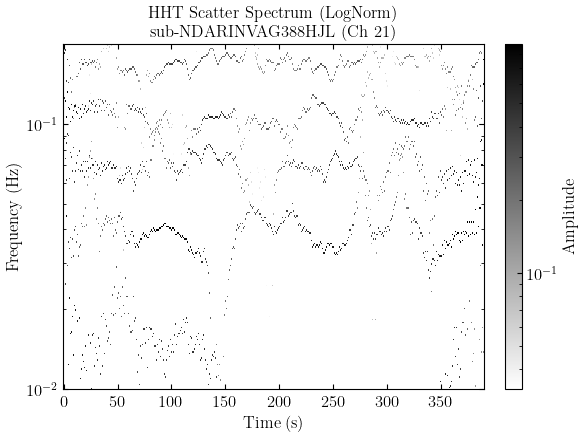

Saved: /Users/ipeglin/Git/masters-thesis-supplementary/figures/plot_hht_spectrogram/sub-NDARINVAG388HJL_ch-21_hht_smoothed_lognorm.pdf


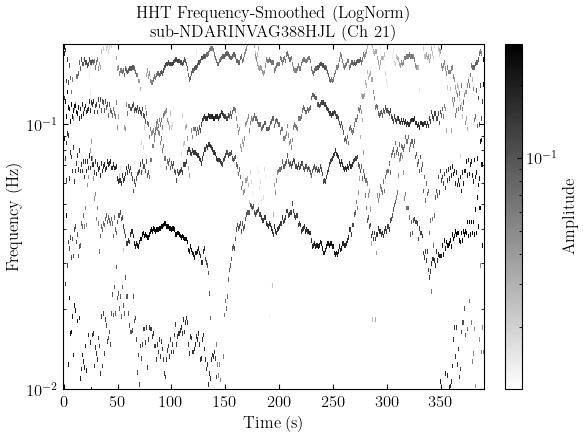

Saved: /Users/ipeglin/Git/masters-thesis-supplementary/figures/plot_hht_spectrogram/sub-NDARINVAG388HJL_ch-21_hht_linear.pdf


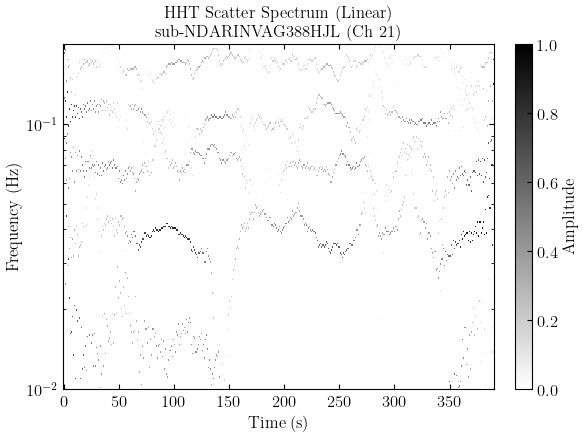

Saved: /Users/ipeglin/Git/masters-thesis-supplementary/figures/plot_hht_spectrogram/sub-NDARINVAG388HJL_ch-21_hht_smoothed_linear.pdf


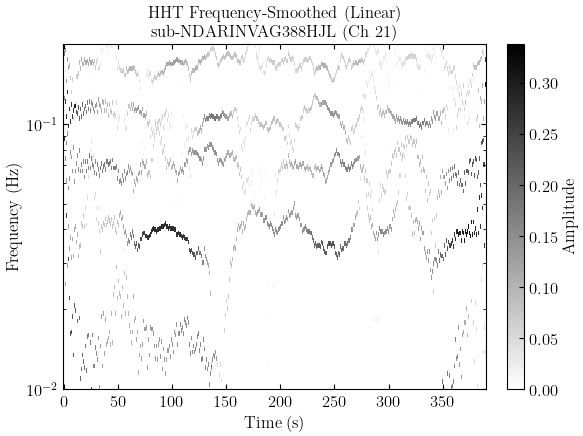

Saved: /Users/ipeglin/Git/masters-thesis-supplementary/figures/plot_hht_spectrogram/sub-NDARINVAG388HJL_ch-21_hht_ie_lognorm.pdf


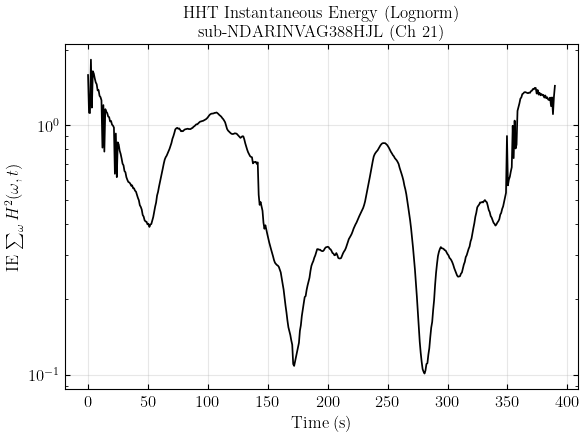

Saved: /Users/ipeglin/Git/masters-thesis-supplementary/figures/plot_hht_spectrogram/sub-NDARINVAG388HJL_ch-21_hht_ie_linear.pdf


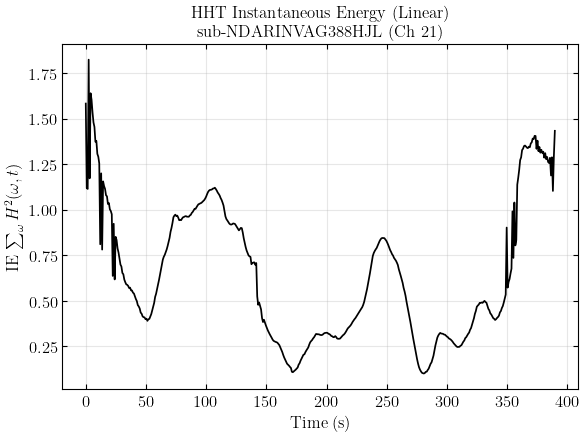

In [18]:
# ---------------------------------------------------------------------------
# Plot helper
# ---------------------------------------------------------------------------
out_dir = REPO_ROOT / "figures" / get_name()
out_dir.mkdir(parents=True, exist_ok=True)


def plot_spectrum_2d(data, title, ch, cmap="gray_r", log_norm=True):
    """Plot [N_BINS, n_t] as a 2D spectrogram with frequency on y-axis."""
    H = data[ch]          # [N_BINS, n_t]  — bin 0 = F_MAX, bin 223 = F_MIN
    H_plot    = H[::-1, :]          # flip: low freq at bottom
    freq_plot = FREQ_AXIS[::-1]

    norm_label = "LogNorm" if log_norm else "Linear"
    if log_norm:
        pos = H_plot[H_plot > 0]
        norm = mcolors.LogNorm(vmin=np.percentile(pos, 1), vmax=np.percentile(pos, 99)) if pos.size > 0 else None
    else:
        norm = None

    fig, ax = plt.subplots()
    mesh = ax.pcolormesh(
        time_axis, freq_plot, H_plot,
        shading="auto", cmap=cmap, norm=norm,
        linewidth=0, antialiased=False, edgecolors="none", rasterized=True,
    )
    ax.set_yscale("log")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Frequency (Hz)")
    ax.set_ylim(F_MIN, F_MAX)
    ax.set_title(f"{title} ({norm_label})\n{subject_id} (Ch {ch})")
    fig.colorbar(mesh, ax=ax, label="Amplitude")
    return fig


for ch in channels_to_plot:
    for log_norm in (True, False):
        norm_label = "lognorm" if log_norm else "linear"

        # --- HHT ---
        fig = plot_spectrum_2d(hht, "HHT Scatter Spectrum", ch, log_norm=log_norm)
        out_path = out_dir / f"{subject_id}_ch-{ch}_hht_{norm_label}.pdf"
        fig.savefig(out_path, format="pdf")
        print(f"Saved: {out_path}")
        plt.show()
        plt.close(fig)

        # --- HHT smoothed ---
        fig = plot_spectrum_2d(hht_smoothed, "HHT Frequency-Smoothed", ch, log_norm=log_norm)
        out_path = out_dir / f"{subject_id}_ch-{ch}_hht_smoothed_{norm_label}.pdf"
        fig.savefig(out_path, format="pdf")
        print(f"Saved: {out_path}")
        plt.show()
        plt.close(fig)

    # --- HHT IE ---
    ie = hht_ie[ch]  # [n_t]
    for log_scale in (True, False):
        scale_label = "lognorm" if log_scale else "linear"
        fig, ax = plt.subplots()
        ax.plot(time_axis, ie, color="k")
        ax.set_xlabel("Time (s)")
        ax.set_ylabel(r"IE  $\sum_\omega H^2(\omega,t)$")
        if log_scale:
            ax.set_yscale("log")
        ax.set_title(f"HHT Instantaneous Energy ({scale_label.capitalize()})\n{subject_id} (Ch {ch})")
        ax.grid(True, alpha=0.3)
        out_path = out_dir / f"{subject_id}_ch-{ch}_hht_ie_{scale_label}.pdf"
        fig.savefig(out_path, format="pdf")
        print(f"Saved: {out_path}")
        plt.show()
        plt.close(fig)